<div style="text-align: center; font-weight: bold;">
    <h1>EHR Preprocessing 3: Natural Language Processing</h1>
    <h4>Author: Vidul Ayakulangara Panickan</h4>
</div>

**Goal:** Learn how to convert clinical free-text notes into structured UMLS Concept Unique Identifiers (CUIs) using dictionary-based NLP. By the end of this notebook, you will have extracted medical concepts from discharge notes and organized them into patient-level CUI counts.

> **Note:** This notebook is a **learning exercise**. We work through the NLP pipeline on a random sample of notes so you understand each step. Notebook 4 (Cohort Creation) independently applies the same pattern to a specific patient cohort.

**Recap:** In Notebooks [1 (Data Cleaning)](EHR_Preprocessing_1_Data_Cleaning.ipynb) and [2 (Code Rollup)](EHR_Preprocessing_2_Code_Rollup.ipynb), we processed **structured** EHR data — diagnosis codes, procedure codes, medications, and lab results. But clinical notes contain a wealth of information that structured codes miss. This notebook unlocks that unstructured free-text data by converting it into analyzable concept codes.
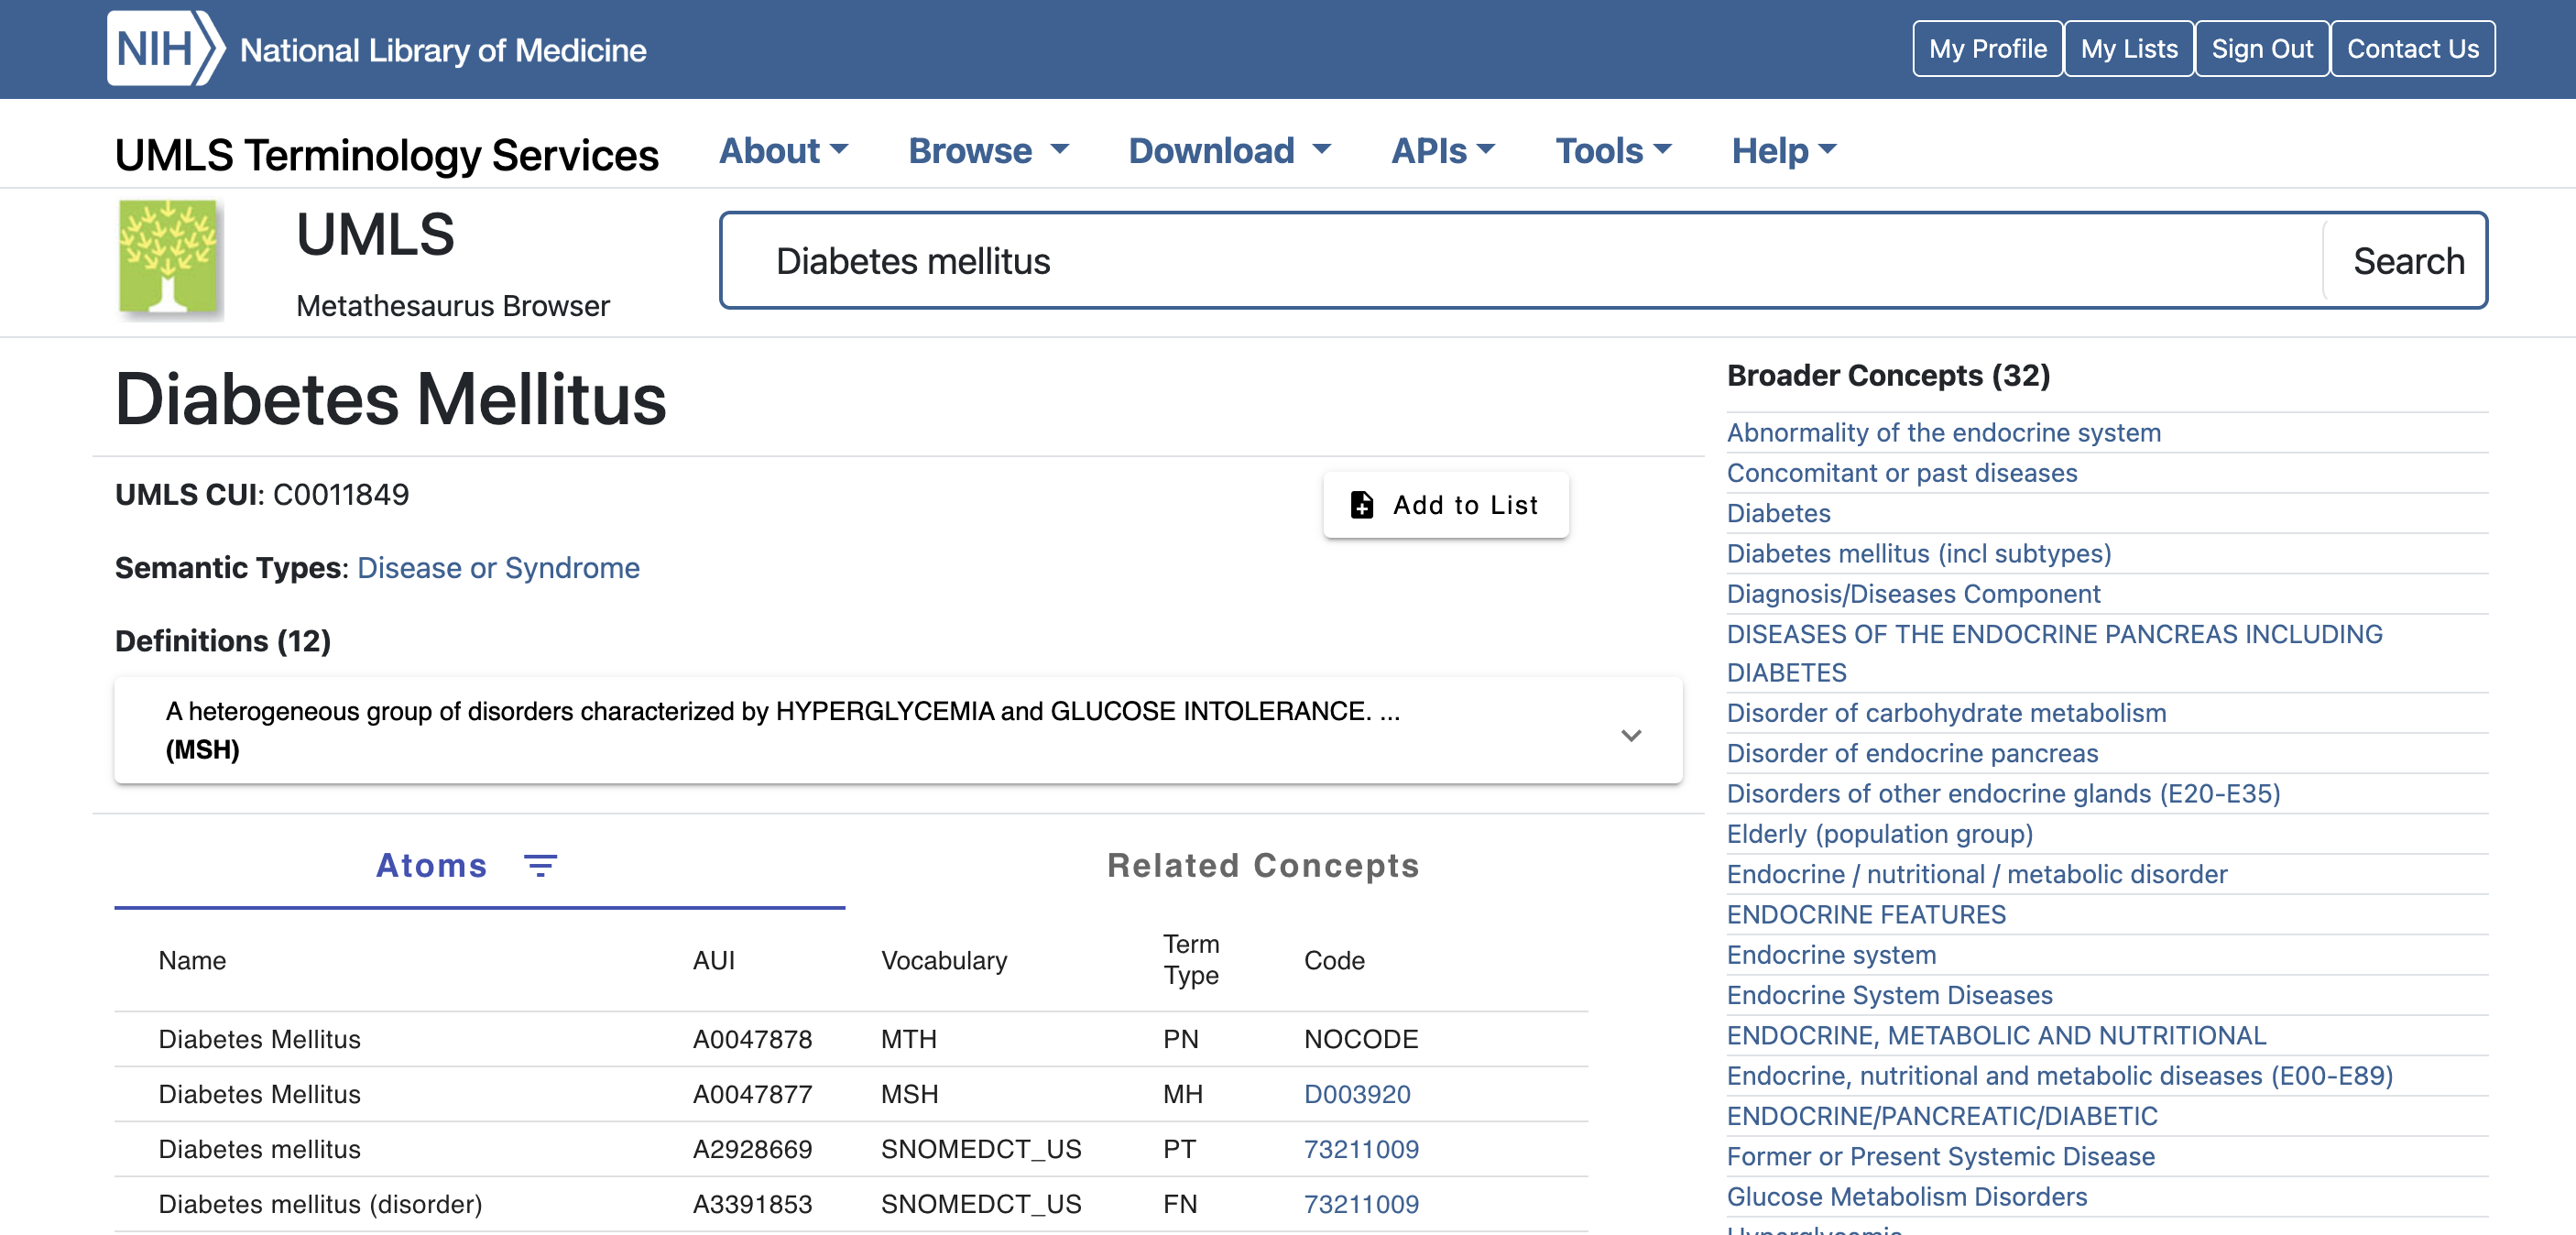

> **Full executable notebook:** [github.com/apvidul/EHR-Processing-Tutorial/TUTORIAL/EHR_Preprocessing_3_Natural_Language_Processing.ipynb](https://github.com/apvidul/EHR-Processing-Tutorial/blob/main/TUTORIAL/EHR_Preprocessing_3_Natural_Language_Processing.ipynb)

## 1. Setup

First, let's import the libraries we need and install `petehr` if it is not already available. The `petehr` package is a lightweight NLP toolkit built for this tutorial — it performs dictionary-based text-to-code conversion. For production use, tools like [NILE](https://celehs.hms.harvard.edu/software/NILE.html) or [cTAKES](https://ctakes.apache.org/) offer higher performance.

In [ ]:
!pip install petehr

import os
import pandas as pd
from petehr import Text2Code

In [ ]:
# Update this path to your EHR_TUTORIAL_WORKSPACE location
base_dir = "EHR_TUTORIAL_WORKSPACE"

note_dir = os.path.join(base_dir, "raw_data", "note_data", "physionet.org", "files", "mimic-iv-note", "2.2", "note")
meta_dir = os.path.join(base_dir, "scripts", "EHR-Processing-Tutorial-main", "meta_files")

## 2. Key Concepts

Before we write any code, let's define the key terms we will use throughout this notebook.

### What is UMLS?

The **Unified Medical Language System (UMLS)** is a collection of more than 200 health and biomedical vocabularies (e.g., ICD, SNOMED-CT, RxNorm, LOINC) maintained by the U.S. National Library of Medicine. Its central function is to map the same clinical concept across different vocabularies to a single identifier.

### What is a CUI?

A **Concept Unique Identifier (CUI)** is UMLS's universal code for a medical concept. For example, the condition *Diabetes mellitus* has the CUI **C0011849**, regardless of which vocabulary you look it up in:

| Concept | CUI | Vocabulary | Code |
|---|---|---|---|
| Diabetes mellitus | C0011849 | WHO | 0371 |
| Diabetes mellitus | C0011849 | SNOMEDCT_US | 73211009 |

You can explore CUIs using the [UMLS Browser](https://uts.nlm.nih.gov/uts/umls/concept/C0011849).

### How Do We Get CUIs from Text?

Given a clinical note, we scan the text for terms that match entries in a **term-to-CUI dictionary**. Each matched term is replaced by its CUI:

| patient_id | date | note |
|---|---|---|
| 10001 | 2012-12-12 | The patient was admitted due to asthma. Secondary diagnosis of DM – Diabetes mellitus. |

After dictionary lookup:

| patient_id | date | extracted CUIs |
|---|---|---|
| 10001 | 2012-12-12 | C0004096, C0011849 |

Where **C0004096** = *Asthma* and **C0011849** = *Diabetes mellitus*.

We use **petehr** (`pip install petehr`) to perform this conversion. It takes a dictionary file and a text string, and returns a comma-separated string of matched CUIs.

### Where Does the Dictionary Come From?

For this tutorial, we use [**ONCE** (Online Narrative and Codified feature Search Engine)](https://shiny.parse-health.org/ONCE/) to obtain a disease-specific term-to-CUI dictionary. ONCE lets you search for a condition (e.g., "Diabetes mellitus"), review the related concepts and synonyms, and download a ready-to-use mapping file.

We chose ONCE because it provides a curated, high-precision dictionary ideal for educational settings. For broader coverage, you can build a comprehensive dictionary from the full UMLS Metathesaurus — see the Appendix at the end of this notebook.

Now that we understand the key concepts, let's load our data and put them into practice.

## 3. Loading Discharge Notes

MIMIC-IV includes several types of clinical notes (discharge summaries, radiology reports, etc.). We will work with **discharge notes**, which summarize a patient's entire hospital stay and are rich in clinical information.

In [ ]:
discharge_notes = pd.read_csv(os.path.join(note_dir, "discharge.csv"), dtype=str)

print(f"Shape: {discharge_notes.shape}")
display(discharge_notes.head())

The dataset contains ~331,000 discharge notes. The key columns for our purposes are:
- `text` — the full discharge note
- `charttime` — when the note was created
- `subject_id` — the patient identifier

Processing all 331K notes would take a long time, so we sample 1,000 notes to keep this tutorial quick.

In [ ]:
note_sample = discharge_notes.sample(1000, random_state=42)

print(f"Sample shape: {note_sample.shape}")

We set `random_state=42` so that everyone running this notebook gets the same sample — this makes results reproducible.

## 4. Loading the NLP Dictionary

We use a diabetes-focused dictionary exported from ONCE. The file contains two columns: `STR` (the terms to search for in clinical text) and `CUI` (the UMLS code each term maps to).

In [ ]:
once_file = os.path.join(meta_dir, "ONCE_Allsyn_phenotype_diabetes_C0011849,C0011860,C0011847_titlecos0.5_titlecut0.3_exactFALSE.csv")
diabetes_dict = pd.read_csv(once_file, dtype=str, sep="|")

print(f"Dictionary shape: {diabetes_dict.shape}")
display(diabetes_dict.head())

The dictionary has ~3,900 term-to-CUI mappings covering ~360 unique CUIs. The `STR` column contains terms like "chronic kidney insufficiency" and "insulin" that petehr will search for in the clinical text. Many synonyms map to the same CUI, which improves recall.

Now we save the dictionary as a comma-separated CSV (the format petehr expects) and initialize the `Text2Code` converter.

In [ ]:
dict_csv_path = os.path.join(meta_dir, "diabetes_nlp_dict.csv")
diabetes_dict.to_csv(dict_csv_path, index=None)
print(f"Saved dictionary to: {dict_csv_path}")

Now we initialize the `Text2Code` converter with our saved dictionary.

In [ ]:
text2cui = Text2Code(dict_csv_path)

`Text2Code` loads the dictionary into memory and prepares it for fast lookups. The "Dictionary loaded successfully" message confirms it is ready. Now let's see it in action.

## 5. Running the NLP Conversion

### Single-Note Demo

Before processing all 1,000 notes, let's convert a single note to understand what the output looks like.

In [ ]:
single_note = note_sample["text"].iloc[0]

print("First 500 characters of the note:")
print(single_note[:500])

In [ ]:
single_result = text2cui.convert(single_note)

print("Extracted CUIs:")
print(single_result[:200])

The output is a comma-separated string of CUI codes. Notice that the same CUI can appear multiple times — this happens when the same medical term (or its synonyms) appears multiple times in the note. We will deduplicate these later.

### Converting All 1,000 Notes

Now let's apply the converter to every note in our sample.

In [ ]:
note_sample["note_cui"] = note_sample["text"].map(text2cui.convert)

display(note_sample[["subject_id", "charttime", "note_cui"]].head())

Each note now has a `note_cui` column containing the comma-separated CUI string. Next, we need to clean and reshape this data into a structured format — one CUI per row, deduplicated per patient-date.

## 6. Cleaning and Reshaping

We will apply several cleaning steps, similar to what we did in the Data Cleaning notebook. We take it one step at a time.

**Step 1: Select columns of interest.** We only need the patient ID, the note date, and the extracted CUIs.

In [ ]:
note_sample = note_sample[["subject_id", "charttime", "note_cui"]]

display(note_sample.head())

**Step 2: Rename and truncate the date.** We rename `charttime` to `date` for consistency with our other datasets, and truncate to `YYYY-MM-DD`.

In [ ]:
note_sample = note_sample.rename(columns={"charttime": "date"})
note_sample["date"] = note_sample["date"].str[:10]

display(note_sample.head())

Notice the dates now show only `YYYY-MM-DD` instead of the full timestamp.

**Step 3: Drop rows where NLP found no matches.** Some notes may not contain any terms from our dictionary. These rows will have `NaN` in `note_cui` and cannot be processed further.

In [ ]:
print(f"Shape before dropping nulls: {note_sample.shape}")

note_sample = note_sample.dropna(subset=["note_cui"])

print(f"Shape after dropping nulls:  {note_sample.shape}")

If no rows were dropped, it means every note in our sample had at least one dictionary match. This is expected for a general medical dictionary applied to discharge notes.

**Step 4: Split the CUI string into a list.** Each `note_cui` cell currently contains a single comma-separated string like `"C0011849,C0004096,C0011849"`. We split it into a Python list so we can expand to one CUI per row in the next step.

In [ ]:
note_sample["note_cui"] = note_sample["note_cui"].str.split(",")

display(note_sample.head())

Notice the `note_cui` column now shows Python lists (e.g., `['C5442411', 'C0005615', ...]`) instead of a single string.

**Step 5: Explode to one CUI per row.** The `explode` function creates a separate row for each CUI in the list, repeating the `subject_id` and `date` values.

In [ ]:
print(f"Shape before explode: {note_sample.shape}")

note_sample = note_sample.explode("note_cui")

print(f"Shape after explode:  {note_sample.shape}")

The row count jumped from 1,000 to ~800,000. This is expected — each note contains many CUI matches, and each match is now its own row.

**Step 6: Deduplicate.** A single note often mentions the same concept multiple times (e.g., "diabetes" might appear 10 times in one note). We only care about *whether* a CUI appeared for a patient on a given date, not how many times within one note. We do this because counting presence (not frequency) is the standard approach for NLP features in EHR research.

In [ ]:
print(f"Shape before dedup: {note_sample.shape}")

note_sample = note_sample.drop_duplicates()

print(f"Shape after dedup:  {note_sample.shape}")

Now we rename the `note_cui` column to `cui` for clarity.

In [ ]:
note_sample = note_sample.rename(columns={"note_cui": "cui"})

display(note_sample.head())

We started with 1,000 notes and ended with unique patient-date-CUI combinations. The deduplication reduced the data significantly, confirming that CUIs were heavily repeated within individual notes.

## 7. Counting CUIs per Patient

Now we count how many times each CUI appeared across all of a patient's notes. This gives us a patient-level summary: for each patient, how many visits mentioned each concept.

In [ ]:
cui_counts = note_sample.groupby(["subject_id", "cui"]).size().reset_index(name="counts")

print(f"Patient-CUI pairs: {cui_counts.shape}")
display(cui_counts.head(10))

Each row shows one patient-CUI pair with the number of distinct dates that CUI was mentioned. For example, a count of 3 means that CUI appeared in notes from 3 different visits.

Let's see which CUIs are most common across all patients.

In [ ]:
top_cuis = cui_counts.groupby("cui")["counts"].sum().sort_values(ascending=False).head(10)

print(f"Top 10 CUIs by total count (out of {cui_counts['cui'].nunique()} unique CUIs):")
print(top_cuis.to_string())

The most frequent CUIs are general medical concepts that appear commonly in discharge notes. You can look up any CUI in the [UMLS Browser](https://uts.nlm.nih.gov/uts/umls/home) to see what concept it represents.

## 8. Validation

Let's verify the final output to make sure everything looks correct.

In [ ]:
print(f"Unique patients:     {cui_counts['subject_id'].nunique()}")
print(f"Unique CUIs:         {cui_counts['cui'].nunique()}")
print(f"Total patient-CUI pairs: {cui_counts.shape[0]}")
print(f"\nOutput schema: {list(cui_counts.columns)}")

This tells us that from 1,000 sampled discharge notes, we extracted CUI features for ~1,000 patients across ~300+ unique medical concepts. The final output has three columns: `subject_id`, `cui`, and `counts` — a clean patient-level representation of the NLP features.

## 9. What We Accomplished

In this notebook, we:

1. **Learned key NLP concepts** — UMLS, CUIs, and dictionary-based text-to-code conversion
2. **Loaded and sampled** discharge notes from MIMIC-IV
3. **Loaded an NLP dictionary** from ONCE and initialized the petehr converter
4. **Converted clinical text to CUIs** — first on a single note to understand the output, then on all 1,000 notes
5. **Cleaned and reshaped** the output — selecting columns, truncating dates, splitting CUI strings, exploding to one CUI per row, and deduplicating
6. **Aggregated CUI counts per patient** into the final `subject_id | cui | counts` format

Notebook 4 (Cohort Creation) applies this same NLP pattern to a specific patient cohort and combines the results with the codified data from Notebooks 1 and 2.

**Next:** In the [Cohort Creation notebook](EHR_Preprocessing_4_Cohort_Creation.ipynb), we will define a patient cohort, extract both codified and NLP features, and aggregate everything into patient-level count matrices ready for analysis.

> **Full executable notebook:** [github.com/apvidul/EHR-Processing-Tutorial/TUTORIAL/EHR_Preprocessing_3_Natural_Language_Processing.ipynb](https://github.com/apvidul/EHR-Processing-Tutorial/blob/main/TUTORIAL/EHR_Preprocessing_3_Natural_Language_Processing.ipynb)

---

## Appendix: Building a UMLS Dictionary from Scratch

If your project requires broader concept coverage beyond what ONCE provides, you can build a comprehensive term-to-CUI dictionary directly from the UMLS Metathesaurus. The source table is **`MRCONSO.RRF`**, which contains lexical variants, synonyms, and source-vocabulary terms linked to CUIs.

**Download:** [UMLS Knowledge Sources](https://www.nlm.nih.gov/research/umls/licensedcontent/umlsknowledgesources.html) (free UMLS license required)

**Recommended extraction filters (for English clinical use):**
- **Language**: `LAT='ENG'`
- **Suppressible flag**: exclude rows with `SUPPRESS='Y'` unless there is a specific reason to include them
- **Source vocabularies**: focus on those relevant to your use case (e.g., SNOMEDCT_US, ICD10CM, RxNorm, LOINC) to balance coverage and precision

**High-level workflow:**
1. **Extract**: Load `MRCONSO.RRF` and filter as above
2. **Normalize**: Lower-case, Unicode-normalize, and optionally strip punctuation in the `STR` column
3. **Deduplicate**: Keep one or more `STR → CUI` entries, prioritizing `TS='P'` (preferred term status), `TTY='PT'` (preferred term type), and highly reliable sources